Connected to base (Python 3.9.13)

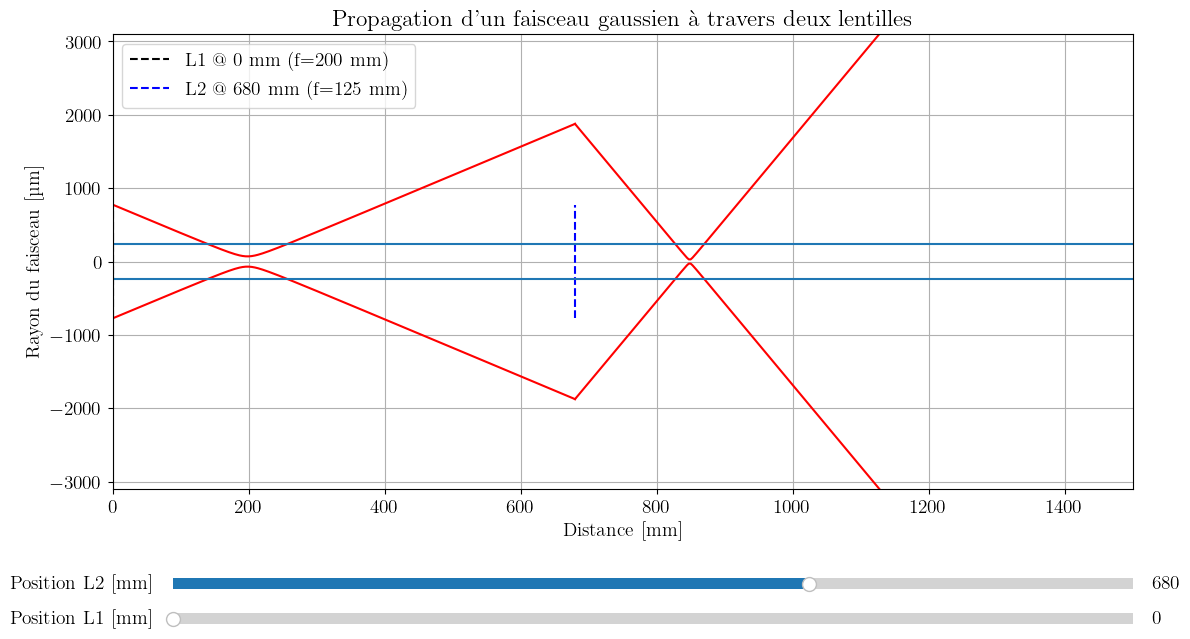

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14
})


# --- Constantes ---
lam0 = 852  # nm
c = 299.8   # nm/fs
pi = np.pi
mirror_size = 0.6 # mm
mirror_idx = 1.5 

# --- Fonctions ---
def round_to(xin, n_round):
    return round(xin, n_round)


# Rayleigh length
def zR(w):
    return pi * w**2 / (lam0 * 1e-6)


# Complex parameter
def q(z, w0):
    return z + 1j * zR(w0)


# Propagation through ABCD matrix
def propagate(confocal, mat):
    A, B = mat[0]
    C, D = mat[1]
    return (A * confocal + B) / (C * confocal + D)


# Waist
def waist(qparam):
    return np.sqrt(qparam.imag * lam0 / pi)


# Beam radius
def beam_radius(qparam):
    return np.sqrt(-(1 / (1 / qparam).imag) * lam0 / pi)


# Matrix through a lenses
def Mf(foc):
    return np.array([[1.0, 0], [-1 / foc, 1.0]])


# Matrix through an interface
def refract_interface(n1,n2) : 
    return np.array([[1,0],[0,n1/n2]])


# Matrix of free space travel
def Md(dist):
    return np.array([[1.0, dist], [0, 1.0]])


# --- Paramètres du système ---
input_waist = 1.55/2  # mm
maxy = input_waist * 1000 * 4

foc1_init = 200  # mm
foc2_init = 125  # mm
pos1_init = 0  # mm
pos2_init = 680  # mm
max_x = 1500  # mm


# Matrix of propagation
def Mprop(x1, x2, x3, f1, f2):#, n1, n2, mirror_size):
    return Md(x3) @ Mf(f2) @ Md(x2) @ Mf(f1) @ Md(x1)


# q-propagation through each segment
def qprop1(x1, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(x1, 0, 0, foc1_init, foc2_init))


def qprop2(x2, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, x2, 0, foc1_init, foc2_init))


def qprop3(x3, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, l2, x3, foc1_init, foc2_init))




# --- Fonction principale de propagation interactive ---
def propagation_interactive(l1, l2):
    x1_vals = np.linspace(0, l1, 300)
    x2_vals = np.linspace(0, l2, 300)
    x3_vals = np.linspace(0, max_x - (l1 + l2), 300)

    r1 = [beam_radius(qprop1(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x1_vals]
    r2 = [beam_radius(qprop2(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x2_vals]
    r3 = [beam_radius(qprop3(x, input_waist, l1, l2, foc1_init, foc2_init))
           for x in x3_vals]

    x2_vals_shifted = x2_vals + l1
    x3_vals_shifted = x3_vals + l1 + l2

    # Lignes verticales pour lentilles
    lens1_x = [l1, l1]
    lens2_x = [l1 + l2, l1 + l2]
    lens_y = [-input_waist * 1000, input_waist * 1000]

    # --- Mise à jour du plot ---
    ax.clear()
    ax.plot(x1_vals, [val for val in r1], 'r')
    ax.plot(x1_vals, [-val for val in r1], 'r')
    ax.plot(x2_vals_shifted, [val for val in r2], 'r')
    ax.plot(x2_vals_shifted, [-val for val in r2], 'r')
    ax.plot(x3_vals_shifted, [val for val in r3], 'r')
    ax.plot(x3_vals_shifted, [-val for val in r3], 'r')

    ax.plot(lens1_x, lens_y, 'k--', linewidth=1.5, label=f'L1 @ {l1} mm (f={foc1_init} mm)')
    ax.plot(lens2_x, lens_y, 'b--', linewidth=1.5, label=f'L2 @ {l1 + l2} mm (f={foc2_init} mm)')

    ax.set_title("Propagation d’un faisceau gaussien à travers deux lentilles")
    ax.set_xlabel("Distance [mm]")
    ax.set_ylabel("Rayon du faisceau [µm]")
    ax.grid(True)
    ax.set_xlim(0, max_x)
    ax.set_ylim(-maxy, maxy)
    ax.axhline(242)
    ax.axhline(-242)
    ax.legend()
    fig.canvas.draw_idle()


# --- Configuration de la figure et des sliders ---
fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95, top=0.9)

ax_l1 = fig.add_axes([0.15, 0.05, 0.8, 0.03])
ax_l2 = fig.add_axes([0.15, 0.1, 0.8, 0.03])

slider_l1 = Slider(ax_l1, 'Position L1 [mm]', 0, 400, valinit=pos1_init, valstep=1)
slider_l2 = Slider(ax_l2, 'Position L2 [mm]', 50, 1000, valinit=pos2_init, valstep=1)


def update(val):
    propagation_interactive(slider_l1.val, slider_l2.val)


slider_l1.on_changed(update)
slider_l2.on_changed(update)

propagation_interactive(slider_l1.valinit, slider_l2.valinit)
plt.show()

In [ ]:
%matplotlib tk

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14
})


# --- Constantes ---
lam0 = 852  # nm
c = 299.8   # nm/fs
pi = np.pi
mirror_size = 0.6 # mm
mirror_idx = 1.5 

# --- Fonctions ---
def round_to(xin, n_round):
    return round(xin, n_round)


# Rayleigh length
def zR(w):
    return pi * w**2 / (lam0 * 1e-6)


# Complex parameter
def q(z, w0):
    return z + 1j * zR(w0)


# Propagation through ABCD matrix
def propagate(confocal, mat):
    A, B = mat[0]
    C, D = mat[1]
    return (A * confocal + B) / (C * confocal + D)


# Waist
def waist(qparam):
    return np.sqrt(qparam.imag * lam0 / pi)


# Beam radius
def beam_radius(qparam):
    return np.sqrt(-(1 / (1 / qparam).imag) * lam0 / pi)


# Matrix through a lenses
def Mf(foc):
    return np.array([[1.0, 0], [-1 / foc, 1.0]])


# Matrix through an interface
def refract_interface(n1,n2) : 
    return np.array([[1,0],[0,n1/n2]])


# Matrix of free space travel
def Md(dist):
    return np.array([[1.0, dist], [0, 1.0]])


# --- Paramètres du système ---
input_waist = 1.55/2  # mm
maxy = input_waist * 1000 * 4

foc1_init = 200  # mm
foc2_init = 125  # mm
pos1_init = 0  # mm
pos2_init = 680  # mm
max_x = 1500  # mm


# Matrix of propagation
def Mprop(x1, x2, x3, f1, f2):#, n1, n2, mirror_size):
    return Md(x3) @ Mf(f2) @ Md(x2) @ Mf(f1) @ Md(x1)


# q-propagation through each segment
def qprop1(x1, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(x1, 0, 0, foc1_init, foc2_init))


def qprop2(x2, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, x2, 0, foc1_init, foc2_init))


def qprop3(x3, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, l2, x3, foc1_init, foc2_init))




# --- Fonction principale de propagation interactive ---
def propagation_interactive(l1, l2):
    x1_vals = np.linspace(0, l1, 300)
    x2_vals = np.linspace(0, l2, 300)
    x3_vals = np.linspace(0, max_x - (l1 + l2), 300)

    r1 = [beam_radius(qprop1(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x1_vals]
    r2 = [beam_radius(qprop2(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x2_vals]
    r3 = [beam_radius(qprop3(x, input_waist, l1, l2, foc1_init, foc2_init))
           for x in x3_vals]

    x2_vals_shifted = x2_vals + l1
    x3_vals_shifted = x3_vals + l1 + l2

    # Lignes verticales pour lentilles
    lens1_x = [l1, l1]
    lens2_x = [l1 + l2, l1 + l2]
    lens_y = [-input_waist * 1000, input_waist * 1000]

    # --- Mise à jour du plot ---
    ax.clear()
    ax.plot(x1_vals, [val for val in r1], 'r')
    ax.plot(x1_vals, [-val for val in r1], 'r')
    ax.plot(x2_vals_shifted, [val for val in r2], 'r')
    ax.plot(x2_vals_shifted, [-val for val in r2], 'r')
    ax.plot(x3_vals_shifted, [val for val in r3], 'r')
    ax.plot(x3_vals_shifted, [-val for val in r3], 'r')

    ax.plot(lens1_x, lens_y, 'k--', linewidth=1.5, label=f'L1 @ {l1} mm (f={foc1_init} mm)')
    ax.plot(lens2_x, lens_y, 'b--', linewidth=1.5, label=f'L2 @ {l1 + l2} mm (f={foc2_init} mm)')

    ax.set_title("Propagation d’un faisceau gaussien à travers deux lentilles")
    ax.set_xlabel("Distance [mm]")
    ax.set_ylabel("Rayon du faisceau [µm]")
    ax.grid(True)
    ax.set_xlim(0, max_x)
    ax.set_ylim(-maxy, maxy)
    ax.axhline(242)
    ax.axhline(-242)
    ax.legend()
    fig.canvas.draw_idle()


# --- Configuration de la figure et des sliders ---
fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95, top=0.9)

ax_l1 = fig.add_axes([0.15, 0.05, 0.8, 0.03])
ax_l2 = fig.add_axes([0.15, 0.1, 0.8, 0.03])

slider_l1 = Slider(ax_l1, 'Position L1 [mm]', 0, 400, valinit=pos1_init, valstep=1)
slider_l2 = Slider(ax_l2, 'Position L2 [mm]', 50, 1000, valinit=pos2_init, valstep=1)


def update(val):
    propagation_interactive(slider_l1.val, slider_l2.val)


slider_l1.on_changed(update)
slider_l2.on_changed(update)

propagation_interactive(slider_l1.valinit, slider_l2.valinit)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider




# --- Constantes ---
lam0 = 852  # nm
c = 299.8   # nm/fs
pi = np.pi
mirror_size = 0.6 # mm
mirror_idx = 1.5 

# --- Fonctions ---
def round_to(xin, n_round):
    return round(xin, n_round)


# Rayleigh length
def zR(w):
    return pi * w**2 / (lam0 * 1e-6)


# Complex parameter
def q(z, w0):
    return z + 1j * zR(w0)


# Propagation through ABCD matrix
def propagate(confocal, mat):
    A, B = mat[0]
    C, D = mat[1]
    return (A * confocal + B) / (C * confocal + D)


# Waist
def waist(qparam):
    return np.sqrt(qparam.imag * lam0 / pi)


# Beam radius
def beam_radius(qparam):
    return np.sqrt(-(1 / (1 / qparam).imag) * lam0 / pi)


# Matrix through a lenses
def Mf(foc):
    return np.array([[1.0, 0], [-1 / foc, 1.0]])


# Matrix through an interface
def refract_interface(n1,n2) : 
    return np.array([[1,0],[0,n1/n2]])


# Matrix of free space travel
def Md(dist):
    return np.array([[1.0, dist], [0, 1.0]])


# --- Paramètres du système ---
input_waist = 1.55/2  # mm
maxy = input_waist * 1000 * 4

foc1_init = 200  # mm
foc2_init = 125  # mm
pos1_init = 0  # mm
pos2_init = 680  # mm
max_x = 1500  # mm


# Matrix of propagation
def Mprop(x1, x2, x3, f1, f2):#, n1, n2, mirror_size):
    return Md(x3) @ Mf(f2) @ Md(x2) @ Mf(f1) @ Md(x1)


# q-propagation through each segment
def qprop1(x1, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(x1, 0, 0, foc1_init, foc2_init))


def qprop2(x2, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, x2, 0, foc1_init, foc2_init))


def qprop3(x3, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, l2, x3, foc1_init, foc2_init))




# --- Fonction principale de propagation interactive ---
def propagation_interactive(l1, l2):
    x1_vals = np.linspace(0, l1, 300)
    x2_vals = np.linspace(0, l2, 300)
    x3_vals = np.linspace(0, max_x - (l1 + l2), 300)

    r1 = [beam_radius(qprop1(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x1_vals]
    r2 = [beam_radius(qprop2(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x2_vals]
    r3 = [beam_radius(qprop3(x, input_waist, l1, l2, foc1_init, foc2_init))
           for x in x3_vals]

    x2_vals_shifted = x2_vals + l1
    x3_vals_shifted = x3_vals + l1 + l2

    # Lignes verticales pour lentilles
    lens1_x = [l1, l1]
    lens2_x = [l1 + l2, l1 + l2]
    lens_y = [-input_waist * 1000, input_waist * 1000]

    # --- Mise à jour du plot ---
    ax.clear()
    ax.plot(x1_vals, [val for val in r1], 'r')
    ax.plot(x1_vals, [-val for val in r1], 'r')
    ax.plot(x2_vals_shifted, [val for val in r2], 'r')
    ax.plot(x2_vals_shifted, [-val for val in r2], 'r')
    ax.plot(x3_vals_shifted, [val for val in r3], 'r')
    ax.plot(x3_vals_shifted, [-val for val in r3], 'r')

    ax.plot(lens1_x, lens_y, 'k--', linewidth=1.5, label=f'L1 @ {l1} mm (f={foc1_init} mm)')
    ax.plot(lens2_x, lens_y, 'b--', linewidth=1.5, label=f'L2 @ {l1 + l2} mm (f={foc2_init} mm)')

    ax.set_title("Propagation d’un faisceau gaussien à travers deux lentilles")
    ax.set_xlabel("Distance [mm]")
    ax.set_ylabel("Rayon du faisceau [µm]")
    ax.grid(True)
    ax.set_xlim(0, max_x)
    ax.set_ylim(-maxy, maxy)
    ax.axhline(242)
    ax.axhline(-242)
    ax.legend()
    fig.canvas.draw_idle()


# --- Configuration de la figure et des sliders ---
fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95, top=0.9)

ax_l1 = fig.add_axes([0.15, 0.05, 0.8, 0.03])
ax_l2 = fig.add_axes([0.15, 0.1, 0.8, 0.03])

slider_l1 = Slider(ax_l1, 'Position L1 [mm]', 0, 400, valinit=pos1_init, valstep=1)
slider_l2 = Slider(ax_l2, 'Position L2 [mm]', 50, 1000, valinit=pos2_init, valstep=1)


def update(val):
    propagation_interactive(slider_l1.val, slider_l2.val)


slider_l1.on_changed(update)
slider_l2.on_changed(update)

propagation_interactive(slider_l1.valinit, slider_l2.valinit)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider




# --- Constantes ---
lam0 = 852  # nm
c = 299.8   # nm/fs
pi = np.pi
mirror_size = 0.6 # mm
mirror_idx = 1.5 

# --- Fonctions ---
def round_to(xin, n_round):
    return round(xin, n_round)


# Rayleigh length
def zR(w):
    return pi * w**2 / (lam0 * 1e-6)


# Complex parameter
def q(z, w0):
    return z + 1j * zR(w0)


# Propagation through ABCD matrix
def propagate(confocal, mat):
    A, B = mat[0]
    C, D = mat[1]
    return (A * confocal + B) / (C * confocal + D)


# Waist
def waist(qparam):
    return np.sqrt(qparam.imag * lam0 / pi)


# Beam radius
def beam_radius(qparam):
    return np.sqrt(-(1 / (1 / qparam).imag) * lam0 / pi)


# Matrix through a lenses
def Mf(foc):
    return np.array([[1.0, 0], [-1 / foc, 1.0]])


# Matrix through an interface
def refract_interface(n1,n2) : 
    return np.array([[1,0],[0,n1/n2]])


# Matrix of free space travel
def Md(dist):
    return np.array([[1.0, dist], [0, 1.0]])


# --- Paramètres du système ---
input_waist = 1.55/2  # mm
maxy = input_waist * 1000 * 4

foc1_init = 200  # mm
foc2_init = 125  # mm
pos1_init = 30  # mm
pos2_init = 400  # mm
max_x = 1500  # mm


# Matrix of propagation
def Mprop(x1, x2, x3, f1, f2):#, n1, n2, mirror_size):
    return Md(x3) @ Mf(f2) @ Md(x2) @ Mf(f1) @ Md(x1)


# q-propagation through each segment
def qprop1(x1, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(x1, 0, 0, foc1_init, foc2_init))


def qprop2(x2, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, x2, 0, foc1_init, foc2_init))


def qprop3(x3, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, l2, x3, foc1_init, foc2_init))




# --- Fonction principale de propagation interactive ---
def propagation_interactive(l1, l2):
    x1_vals = np.linspace(0, l1, 300)
    x2_vals = np.linspace(0, l2, 300)
    x3_vals = np.linspace(0, max_x - (l1 + l2), 300)

    r1 = [beam_radius(qprop1(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x1_vals]
    r2 = [beam_radius(qprop2(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x2_vals]
    r3 = [beam_radius(qprop3(x, input_waist, l1, l2, foc1_init, foc2_init))
           for x in x3_vals]

    x2_vals_shifted = x2_vals + l1
    x3_vals_shifted = x3_vals + l1 + l2

    # Lignes verticales pour lentilles
    lens1_x = [l1, l1]
    lens2_x = [l1 + l2, l1 + l2]
    lens_y = [-input_waist * 1000, input_waist * 1000]

    # --- Mise à jour du plot ---
    ax.clear()
    ax.plot(x1_vals, [val for val in r1], 'r')
    ax.plot(x1_vals, [-val for val in r1], 'r')
    ax.plot(x2_vals_shifted, [val for val in r2], 'r')
    ax.plot(x2_vals_shifted, [-val for val in r2], 'r')
    ax.plot(x3_vals_shifted, [val for val in r3], 'r')
    ax.plot(x3_vals_shifted, [-val for val in r3], 'r')

    ax.plot(lens1_x, lens_y, 'k--', linewidth=1.5, label=f'L1 @ {l1} mm (f={foc1_init} mm)')
    ax.plot(lens2_x, lens_y, 'b--', linewidth=1.5, label=f'L2 @ {l1 + l2} mm (f={foc2_init} mm)')

    ax.set_title("Propagation d’un faisceau gaussien à travers deux lentilles")
    ax.set_xlabel("Distance [mm]")
    ax.set_ylabel("Rayon du faisceau [µm]")
    ax.grid(True)
    ax.set_xlim(0, max_x)
    ax.set_ylim(-maxy, maxy)
    ax.axhline(242)
    ax.axhline(-242)
    ax.legend()
    fig.canvas.draw_idle()


# --- Configuration de la figure et des sliders ---
fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95, top=0.9)

ax_l1 = fig.add_axes([0.15, 0.05, 0.8, 0.03])
ax_l2 = fig.add_axes([0.15, 0.1, 0.8, 0.03])

slider_l1 = Slider(ax_l1, 'Position L1 [mm]', 0, 400, valinit=pos1_init, valstep=1)
slider_l2 = Slider(ax_l2, 'Position L2 [mm]', 50, 1000, valinit=pos2_init, valstep=1)


def update(val):
    propagation_interactive(slider_l1.val, slider_l2.val)


slider_l1.on_changed(update)
slider_l2.on_changed(update)

propagation_interactive(slider_l1.valinit, slider_l2.valinit)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider




# --- Constantes ---
lam0 = 852  # nm
c = 299.8   # nm/fs
pi = np.pi
mirror_size = 0.6 # mm
mirror_idx = 1.5 

# --- Fonctions ---
def round_to(xin, n_round):
    return round(xin, n_round)


# Rayleigh length
def zR(w):
    return pi * w**2 / (lam0 * 1e-6)


# Complex parameter
def q(z, w0):
    return z + 1j * zR(w0)


# Propagation through ABCD matrix
def propagate(confocal, mat):
    A, B = mat[0]
    C, D = mat[1]
    return (A * confocal + B) / (C * confocal + D)


# Waist
def waist(qparam):
    return np.sqrt(qparam.imag * lam0 / pi)


# Beam radius
def beam_radius(qparam):
    return np.sqrt(-(1 / (1 / qparam).imag) * lam0 / pi)


# Matrix through a lenses
def Mf(foc):
    return np.array([[1.0, 0], [-1 / foc, 1.0]])


# Matrix through an interface
def refract_interface(n1,n2) : 
    return np.array([[1,0],[0,n1/n2]])


# Matrix of free space travel
def Md(dist):
    return np.array([[1.0, dist], [0, 1.0]])


# --- Paramètres du système ---
input_waist = 1.55/2  # mm
maxy = input_waist * 1000 * 4

foc1_init = 200  # mm
foc2_init = 125  # mm
pos1_init = 30  # mm
pos2_init = 355  # mm
max_x = 1500  # mm


# Matrix of propagation
def Mprop(x1, x2, x3, f1, f2):#, n1, n2, mirror_size):
    return Md(x3) @ Mf(f2) @ Md(x2) @ Mf(f1) @ Md(x1)


# q-propagation through each segment
def qprop1(x1, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(x1, 0, 0, foc1_init, foc2_init))


def qprop2(x2, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, x2, 0, foc1_init, foc2_init))


def qprop3(x3, input_waist, l1, l2, foc1_init, foc2_init):
    return propagate(q(0, input_waist), Mprop(l1, l2, x3, foc1_init, foc2_init))




# --- Fonction principale de propagation interactive ---
def propagation_interactive(l1, l2):
    x1_vals = np.linspace(0, l1, 300)
    x2_vals = np.linspace(0, l2, 300)
    x3_vals = np.linspace(0, max_x - (l1 + l2), 300)

    r1 = [beam_radius(qprop1(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x1_vals]
    r2 = [beam_radius(qprop2(x, input_waist, l1, l2, foc1_init, foc2_init)) 
          for x in x2_vals]
    r3 = [beam_radius(qprop3(x, input_waist, l1, l2, foc1_init, foc2_init))
           for x in x3_vals]

    x2_vals_shifted = x2_vals + l1
    x3_vals_shifted = x3_vals + l1 + l2

    # Lignes verticales pour lentilles
    lens1_x = [l1, l1]
    lens2_x = [l1 + l2, l1 + l2]
    lens_y = [-input_waist * 1000, input_waist * 1000]

    # --- Mise à jour du plot ---
    ax.clear()
    ax.plot(x1_vals, [val for val in r1], 'r')
    ax.plot(x1_vals, [-val for val in r1], 'r')
    ax.plot(x2_vals_shifted, [val for val in r2], 'r')
    ax.plot(x2_vals_shifted, [-val for val in r2], 'r')
    ax.plot(x3_vals_shifted, [val for val in r3], 'r')
    ax.plot(x3_vals_shifted, [-val for val in r3], 'r')

    ax.plot(lens1_x, lens_y, 'k--', linewidth=1.5, label=f'L1 @ {l1} mm (f={foc1_init} mm)')
    ax.plot(lens2_x, lens_y, 'b--', linewidth=1.5, label=f'L2 @ {l1 + l2} mm (f={foc2_init} mm)')

    ax.set_title("Propagation of a gaussian beam through two lenses")
    ax.set_xlabel("Distance [mm]")
    ax.set_ylabel("Beam waist [µm]")
    ax.grid(True)
    ax.set_xlim(0, max_x)
    ax.set_ylim(-maxy, maxy)
    ax.axhline(242)
    ax.axhline(-242)
    ax.legend()
    fig.canvas.draw_idle()


# --- Configuration de la figure et des sliders ---
fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95, top=0.9)

ax_l1 = fig.add_axes([0.15, 0.05, 0.8, 0.03])
ax_l2 = fig.add_axes([0.15, 0.1, 0.8, 0.03])

slider_l1 = Slider(ax_l1, 'Position L1 [mm]', 0, 400, valinit=pos1_init, valstep=1)
slider_l2 = Slider(ax_l2, 'Position L2 [mm]', 50, 1000, valinit=pos2_init, valstep=1)


def update(val):
    propagation_interactive(slider_l1.val, slider_l2.val)


slider_l1.on_changed(update)
slider_l2.on_changed(update)

propagation_interactive(slider_l1.valinit, slider_l2.valinit)
plt.show()